# 🎓 Economic Complexity Analysis with py-ecomplexity (Harvard)

We use the [py-ecomplexity](https://github.com/cid-harvard/py-ecomplexity) library from Harvard's Growth Lab to compute complexity indices from the WIPO Innovation Capabilities Outlook 2026 data.

**Calculated indices:** ECI, PCI, RCA, Density, COI, COG

In [1]:
%pip install ecomplexity pyarrow -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from ecomplexity import ecomplexity

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif', 'font.size': 10, 'axes.titlesize': 13, 'axes.labelsize': 11})

DIM_COLORS = {'Production': '#00B0F0', 'Entrepreneurial': '#C5E0B4', 'Technology': '#2E75B6', 'Science': '#A9D18E'}
DIM_LABELS = {'P': 'Production', 'T': 'Technology', 'S': 'Science', 'E': 'Entrepreneurial'}
CONT_COLORS = {
    'Africa': '#9DC3E6', 'Europe': '#2E75B6', 'Oceania': '#A9D18E',
    'East Asia': '#548235', 'Northern America': '#BDD7EE',
    'West and Central Asia': '#C5E0B4', 'Latin America and the Caribbean': '#00B0F0',
}
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Data loading (memory efficient)
We only load the **last 3 years** (2021-2023) and process each dimension separately.

In [3]:
fields = pd.read_parquet('data/fields.parquet')
units = pd.read_parquet('data/units.parquet')
uc_wipo = pd.read_parquet('data/unit_complexities.parquet')
fc_wipo = pd.read_parquet('data/field_complexities.parquet')

outputs_full = pd.read_parquet('data/outputs.parquet', columns=['Period', 'Unit', 'Dimension', 'Field ID', 'Outputs (Fractional)'])
outputs_recent = outputs_full[outputs_full['Period'].isin([2021, 2022, 2023])].copy()
del outputs_full

print(f'Outputs cargados (2021-2023): {outputs_recent.shape[0]:,} filas')
print(f'Dimensiones: {outputs_recent["Dimension"].value_counts().to_dict()}')

Outputs cargados (2021-2023): 881,990 filas
Dimensiones: {'P': 493926, 'S': 175340, 'E': 135156, 'T': 77568}


## 2. Cálculo de Complejidad por Dimensión

In [4]:
trade_cols = {'time': 'Period', 'loc': 'Unit', 'prod': 'Field ID', 'val': 'Outputs (Fractional)'}

results = {}
for dim_code in ['P', 'T', 'S', 'E']:
    dim_name = DIM_LABELS[dim_code]
    print(f'\n{"="*50}\nProcesando: {dim_name} ({dim_code})\n{"="*50}')
    
    dim_data = outputs_recent[outputs_recent['Dimension'] == dim_code][[
        'Period', 'Unit', 'Field ID', 'Outputs (Fractional)'
    ]].copy()
    dim_data = dim_data[dim_data['Outputs (Fractional)'] > 0].dropna()
    print(f'Filas: {dim_data.shape[0]:,}')
    
    result = ecomplexity(dim_data, trade_cols)
    result['Dimension'] = dim_code
    results[dim_code] = result
    
    r2023 = result[result['Period'] == 2023]
    eci_top = r2023.drop_duplicates('Unit').nlargest(5, 'eci')
    print(f'\nTop 5 ECI ({dim_name}, 2023):')
    for _, row in eci_top.iterrows():
        print(f'  {row["Unit"]:>4s}: ECI = {row["eci"]:.3f}')

all_results = pd.concat(results.values(), ignore_index=True)
print(f'\n✅ Total resultados: {all_results.shape[0]:,} filas')


Procesando: Production (P)
Filas: 336,994
2021
Percentage of pairs compared that meet log-supermodularity condition: 48.20%
2022
Percentage of pairs compared that meet log-supermodularity condition: 39.39%
2023
Percentage of pairs compared that meet log-supermodularity condition: 19.46%

Top 5 ECI (Production, 2023):
    JP: ECI = 2.522
    CH: ECI = 2.322
    KR: ECI = 2.218
    DE: ECI = 2.141
    SG: ECI = 2.055

Procesando: Technology (T)
Filas: 77,568
2021
Percentage of pairs compared that meet log-supermodularity condition: 6.16%
2022
Percentage of pairs compared that meet log-supermodularity condition: 5.16%
2023
Percentage of pairs compared that meet log-supermodularity condition: 9.48%

Top 5 ECI (Technology, 2023):
    PG: ECI = 2.377
    BI: ECI = 2.147
    DE: ECI = 1.409
    KI: ECI = 1.396
    IT: ECI = 1.385

Procesando: Science (S)
Filas: 175,340
2021
Percentage of pairs compared that meet log-supermodularity condition: 16.41%
2022
Percentage of pairs compared that mee

## 3. Rankings ECI por Dimensión (2023)

In [5]:
units_2023 = units[units['Period'] == 2023][['Unit', 'Unit Name', 'Continent', 'GDP PC']]

eci_pivot = pd.DataFrame()
for dim_code, dim_name in DIM_LABELS.items():
    r = results[dim_code]
    r2023 = r[r['Period'] == 2023].drop_duplicates('Unit')[['Unit', 'eci']].rename(columns={'eci': f'ECI_{dim_name}'})
    if eci_pivot.empty:
        eci_pivot = r2023
    else:
        eci_pivot = eci_pivot.merge(r2023, on='Unit', how='outer')

eci_pivot = eci_pivot.merge(units_2023, on='Unit', how='left')
eci_pivot['ECI_avg'] = eci_pivot[[f'ECI_{d}' for d in DIM_LABELS.values()]].mean(axis=1)

top20 = eci_pivot.nlargest(20, 'ECI_avg')[['Unit Name', 'ECI_Production', 'ECI_Technology', 'ECI_Science', 'ECI_Entrepreneurial', 'ECI_avg']].reset_index(drop=True)
top20.index += 1
print('🏆 Top 20 países por ECI promedio (py-ecomplexity, 2023):')
display(top20.style.format('{:.3f}', subset=[c for c in top20.columns if 'ECI' in c]).background_gradient(subset=['ECI_avg'], cmap='Blues'))

🏆 Top 20 países por ECI promedio (py-ecomplexity, 2023):


,Unit Name,ECI_Production,ECI_Technology,ECI_Science,ECI_Entrepreneurial,ECI_avg
1,Czech Republic (the),1.893,1.162,0.492,1.152,1.175
2,Singapore,2.055,0.232,1.530,0.806,1.156
3,Slovakia,1.420,1.173,0.734,1.128,1.114
4,Malta,1.351,0.728,0.254,2.110,1.111
5,Saudi Arabia,0.455,1.110,2.106,0.572,1.061
6,Germany,2.141,1.409,-0.376,0.980,1.039
7,Slovenia,1.834,1.075,0.672,0.417,1.000
8,Austria,1.793,1.377,-0.319,1.113,0.991
9,Luxembourg,1.477,1.071,0.263,0.987,0.949
10,United Kingdom (the),2.033,1.082,-0.704,1.343,0.938


In [6]:
chile_eci = eci_pivot[eci_pivot['Unit'] == 'CL']
print('🇨🇱 Chile - ECI por dimensión (2023):')
for dim_name in DIM_LABELS.values():
    col = f'ECI_{dim_name}'
    val = chile_eci[col].values[0]
    rank = (eci_pivot[col] > val).sum() + 1
    total = eci_pivot[col].notna().sum()
    print(f'  {dim_name:20s}: ECI = {val:+.3f}  (#{rank}/{total})')

avg = chile_eci['ECI_avg'].values[0]
rank = (eci_pivot['ECI_avg'] > avg).sum() + 1
print(f'  {"Promedio":20s}: ECI = {avg:+.3f}  (#{rank}/{len(eci_pivot)})')

🇨🇱 Chile - ECI por dimensión (2023):
  Production          : ECI = -0.522  (#126/191)
  Technology          : ECI = +1.031  (#29/179)
  Science             : ECI = -0.052  (#92/192)
  Entrepreneurial     : ECI = +0.247  (#72/177)
  Promedio            : ECI = +0.176  (#83/193)


## 4. Comparación: py-ecomplexity vs WIPO pre-computado

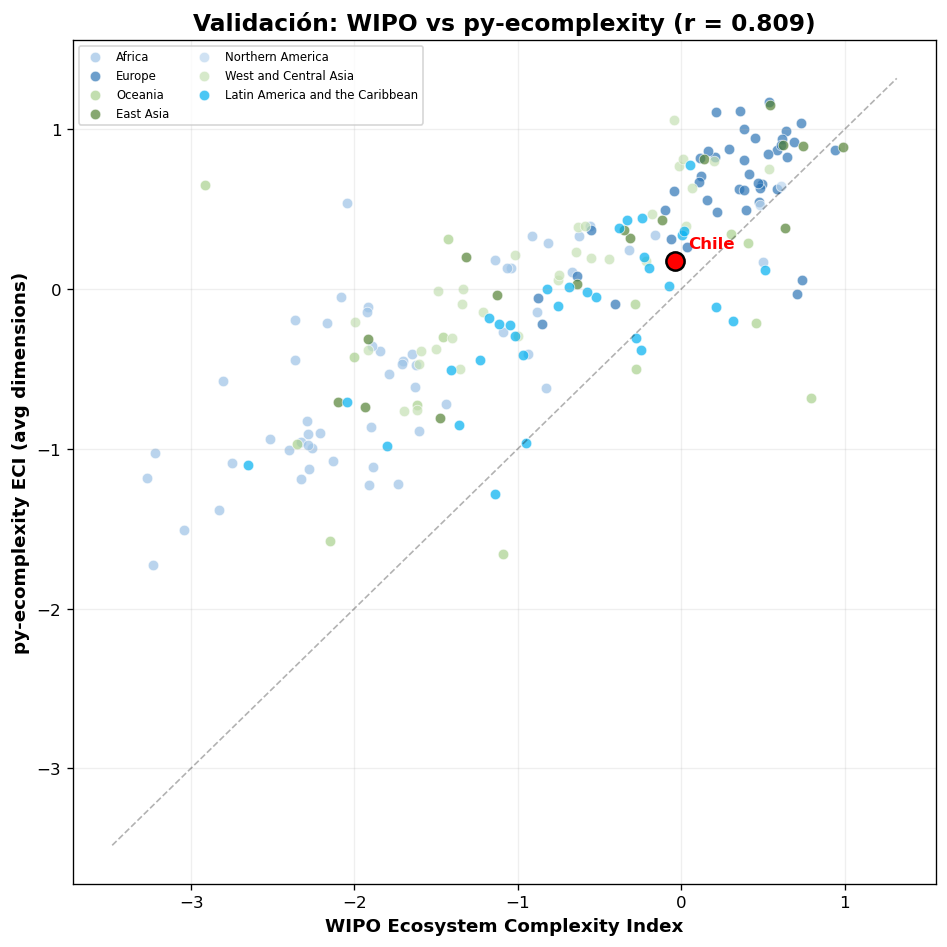

Correlación Pearson: 0.8095
Correlación Spearman: 0.8150


In [7]:
wipo_2023 = uc_wipo[uc_wipo['Period'] == 2023][['Unit', 'Ecosystem Complexity Index']]
comparison = eci_pivot[['Unit', 'ECI_avg']].merge(wipo_2023, on='Unit', how='inner')

fig, ax = plt.subplots(figsize=(8, 8))
comp_with_cont = comparison.merge(units_2023[['Unit', 'Continent']], on='Unit', how='left')
for cont, color in CONT_COLORS.items():
    mask = comp_with_cont['Continent'] == cont
    subset = comp_with_cont[mask]
    ax.scatter(subset['Ecosystem Complexity Index'], subset['ECI_avg'], c=color, s=40, alpha=0.7, label=cont, edgecolors='white', linewidth=0.5)

chile_comp = comp_with_cont[comp_with_cont['Unit'] == 'CL']
if not chile_comp.empty:
    ax.scatter(chile_comp['Ecosystem Complexity Index'], chile_comp['ECI_avg'], c='red', s=120, zorder=5, edgecolors='black', linewidth=1.5)
    ax.annotate('Chile', (chile_comp['Ecosystem Complexity Index'].values[0], chile_comp['ECI_avg'].values[0]),
                fontsize=10, fontweight='bold', color='red', xytext=(8, 8), textcoords='offset points')

corr = comparison['ECI_avg'].corr(comparison['Ecosystem Complexity Index'])
ax.set_xlabel('WIPO Ecosystem Complexity Index', fontweight='bold')
ax.set_ylabel('py-ecomplexity ECI (avg dimensions)', fontweight='bold')
ax.set_title(f'Validación: WIPO vs py-ecomplexity (r = {corr:.3f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
plt.tight_layout()
plt.savefig('validation_eci_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlación Pearson: {corr:.4f}')
print(f'Correlación Spearman: {comparison["ECI_avg"].corr(comparison["Ecosystem Complexity Index"], method="spearman"):.4f}')

## 5. 🇨🇱 Análisis RCA de Chile por Dominio (Gráfico de Barras)

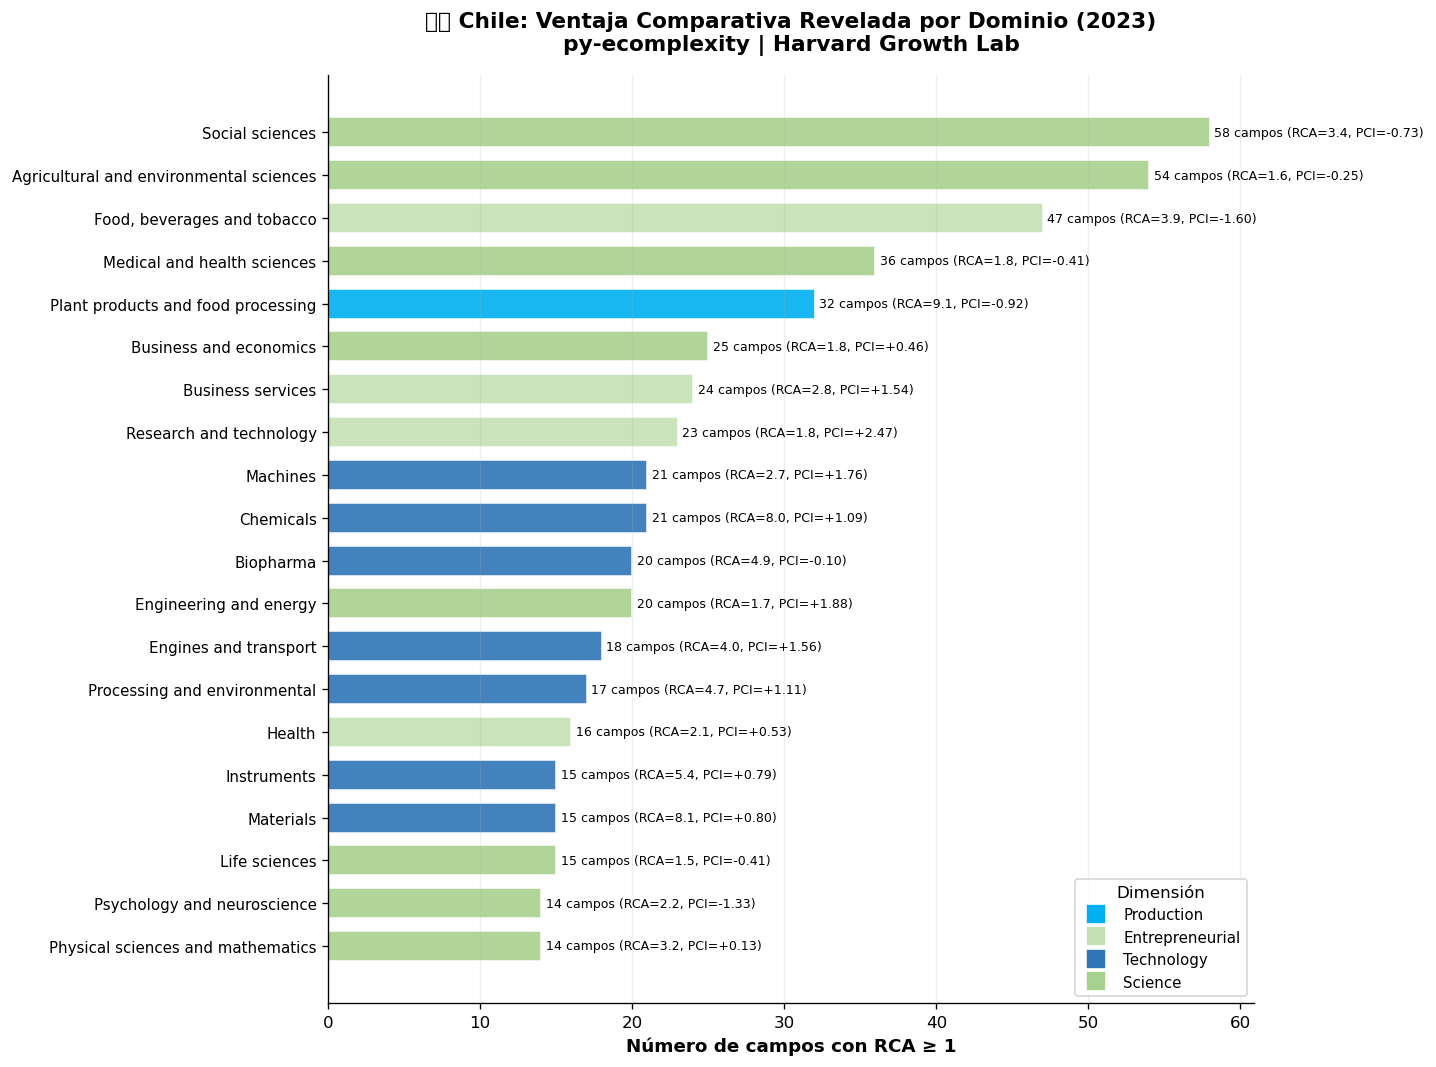

Total campos con RCA ≥ 1 para Chile: 661


In [8]:
chile_all = all_results[(all_results['Unit'] == 'CL') & (all_results['Period'] == 2023)].copy()
chile_all = chile_all.merge(fields, on='Field ID', how='left')

chile_rca = chile_all[chile_all['rca'] >= 1]
rca_by_domain = chile_rca.groupby(['Domain Name', 'Dimension Name']).agg(
    fields_with_rca=('rca', 'count'),
    avg_rca=('rca', 'mean'),
    avg_pci=('pci', 'mean'),
).reset_index().sort_values('fields_with_rca', ascending=True)

top_domains = rca_by_domain.tail(20)

fig, ax = plt.subplots(figsize=(12, 9))
colors = [DIM_COLORS.get(d, '#999') for d in top_domains['Dimension Name']]
bars = ax.barh(range(len(top_domains)), top_domains['fields_with_rca'], color=colors,
               edgecolor='white', height=0.7, alpha=0.9)
ax.set_yticks(range(len(top_domains)))
ax.set_yticklabels(top_domains['Domain Name'], fontsize=9)

for i, (cnt, rca, pci) in enumerate(zip(top_domains['fields_with_rca'], top_domains['avg_rca'], top_domains['avg_pci'])):
    ax.text(cnt + 0.3, i, f'{cnt} campos (RCA={rca:.1f}, PCI={pci:+.2f})', va='center', fontsize=7.5)

legend_elements = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=12, label=d)
                   for d, c in DIM_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Dimensión', title_fontsize=10)
ax.set_xlabel('Número de campos con RCA ≥ 1', fontsize=11, fontweight='bold')
ax.set_title('🇨🇱 Chile: Ventaja Comparativa Revelada por Dominio (2023)\npy-ecomplexity | Harvard Growth Lab',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chile_rca_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total campos con RCA ≥ 1 para Chile: {len(chile_rca)}')

## 6. 🇨🇱 Chile: Oportunidades Estratégicas (Alta Densidad + Alto PCI, sin RCA)

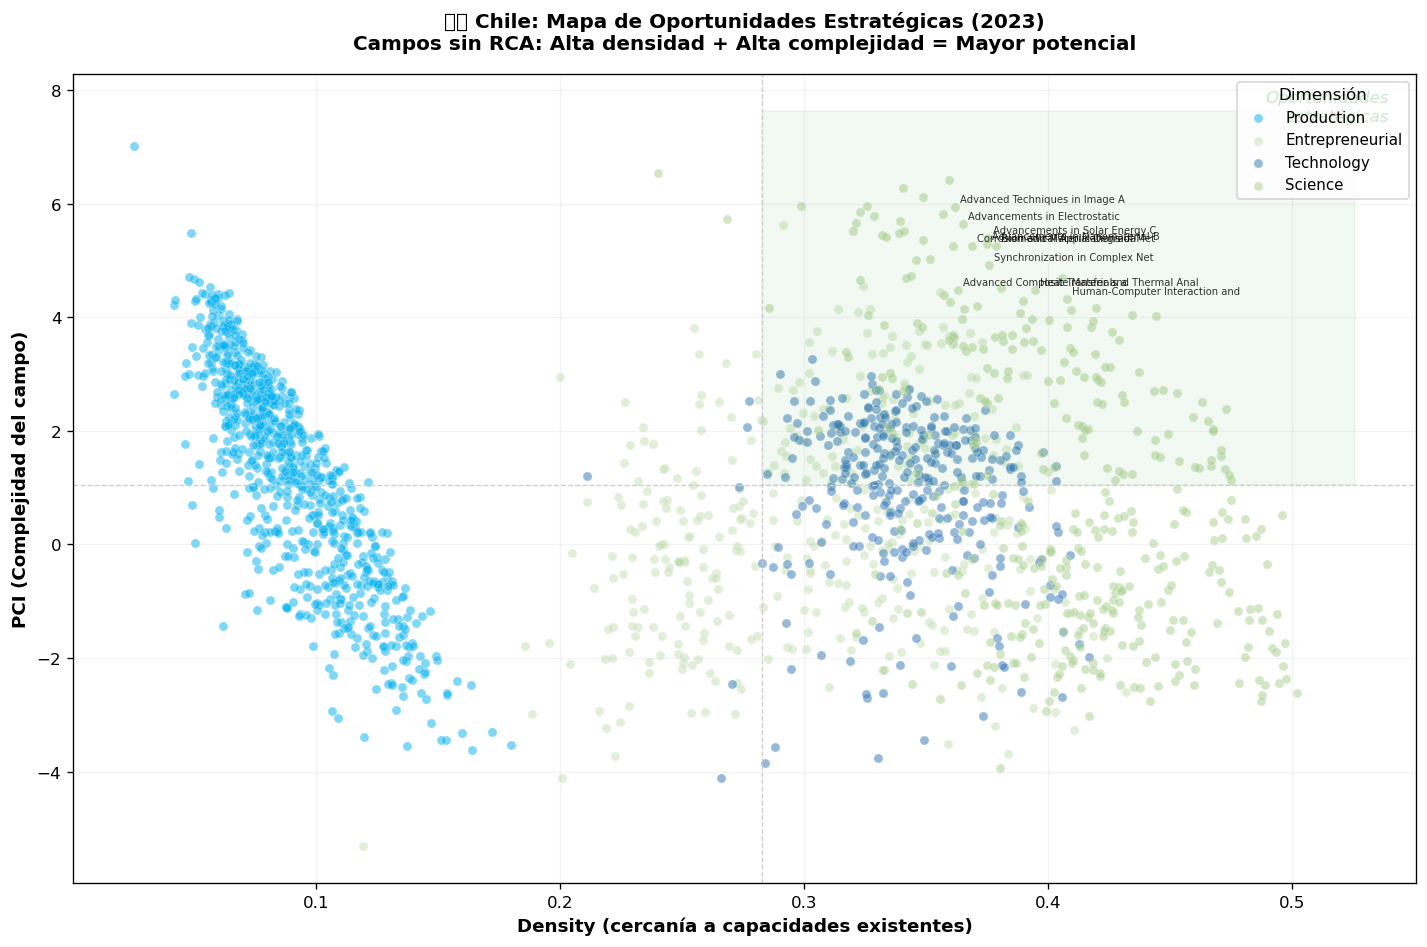

Campos en zona estratégica: 85


In [9]:
chile_no_rca = chile_all[chile_all['rca'] < 1].copy()
chile_no_rca = chile_no_rca.dropna(subset=['density', 'pci'])

fig, ax = plt.subplots(figsize=(12, 8))
for dim, color in DIM_COLORS.items():
    mask = chile_no_rca['Dimension Name'] == dim
    subset = chile_no_rca[mask]
    ax.scatter(subset['density'], subset['pci'], c=color, s=30, alpha=0.5, label=dim, edgecolors='white', linewidth=0.3)

med_dens = chile_no_rca['density'].median()
med_pci = chile_no_rca['pci'].median()
strategic = chile_no_rca[(chile_no_rca['density'] > chile_no_rca['density'].quantile(0.75)) & 
                         (chile_no_rca['pci'] > chile_no_rca['pci'].quantile(0.75))]

for _, row in strategic.nlargest(10, 'cog').iterrows():
    label = row['Field Name'][:30] if isinstance(row['Field Name'], str) else str(row['Field ID'])
    ax.annotate(label, (row['density'], row['pci']), fontsize=6, alpha=0.8, 
                xytext=(3, 3), textcoords='offset points')

ax.axhline(med_pci, color='#ccc', linewidth=0.8, linestyle='--')
ax.axvline(med_dens, color='#ccc', linewidth=0.8, linestyle='--')
ax.fill_between([med_dens, ax.get_xlim()[1]], med_pci, ax.get_ylim()[1], alpha=0.05, color='green')
ax.text(0.98, 0.98, 'Oportunidades\nestratégicas', transform=ax.transAxes, ha='right', va='top', 
        fontsize=10, color='green', fontstyle='italic')

ax.set_xlabel('Density (cercanía a capacidades existentes)', fontsize=11, fontweight='bold')
ax.set_ylabel('PCI (Complejidad del campo)', fontsize=11, fontweight='bold')
ax.set_title('🇨🇱 Chile: Mapa de Oportunidades Estratégicas (2023)\nCampos sin RCA: Alta densidad + Alta complejidad = Mayor potencial',
             fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=9, title='Dimensión')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('chile_strategic_opportunities.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Campos en zona estratégica: {len(strategic)}')

In [10]:
strat_table = strategic.nlargest(20, 'cog')[['Field Name', 'Domain Name', 'Dimension Name', 'density', 'pci', 'cog']].reset_index(drop=True)
strat_table.index += 1
strat_table.columns = ['Campo', 'Dominio', 'Dimensión', 'Densidad', 'PCI', 'COG']
print('🎯 Top 20 oportunidades estratégicas para Chile (mayor Complexity Outlook Gain):')
display(strat_table.style.format({'Densidad': '{:.3f}', 'PCI': '{:+.3f}', 'COG': '{:+.4f}'}).background_gradient(subset=['COG'], cmap='Greens'))

🎯 Top 20 oportunidades estratégicas para Chile (mayor Complexity Outlook Gain):


,Campo,Dominio,Dimensión,Densidad,PCI,COG
1,Advancements in Electrostatic Applications and Technologies,Engineering and energy,Science,0.365,+5.645,+1.3138
2,Advancements in Solar Energy Conversion Technologies,Engineering and energy,Science,0.375,+5.397,+1.2333
3,Biomedical Applications of Metal Alloys and Nanomaterials,Physical sciences and mathematics,Science,0.378,+5.248,+1.2275
4,Advancements in Nanomaterial-Based Sensor Technologies,Engineering and energy,Science,0.375,+5.282,+1.1820
5,Corrosion and Material Degradation in Metals,Physical sciences and mathematics,Science,0.369,+5.256,+1.1719
6,Advanced Techniques in Image Analysis and Processing,Computer science,Science,0.362,+5.936,+1.1669
7,Synchronization in Complex Networked Systems,Computer science,Science,0.376,+4.911,+1.1465
8,Heat Transfer and Thermal Analysis Across Disciplines,Engineering and energy,Science,0.394,+4.479,+1.1201
9,Advanced Composite Materials and Structural Analysis,Engineering and energy,Science,0.363,+4.479,+1.1129
10,Human-Computer Interaction and Recognition Technologies,Computer science,Science,0.408,+4.323,+1.1098


## 7. 🇨🇱 Chile: COG por Dominio - Gráfico de Barras

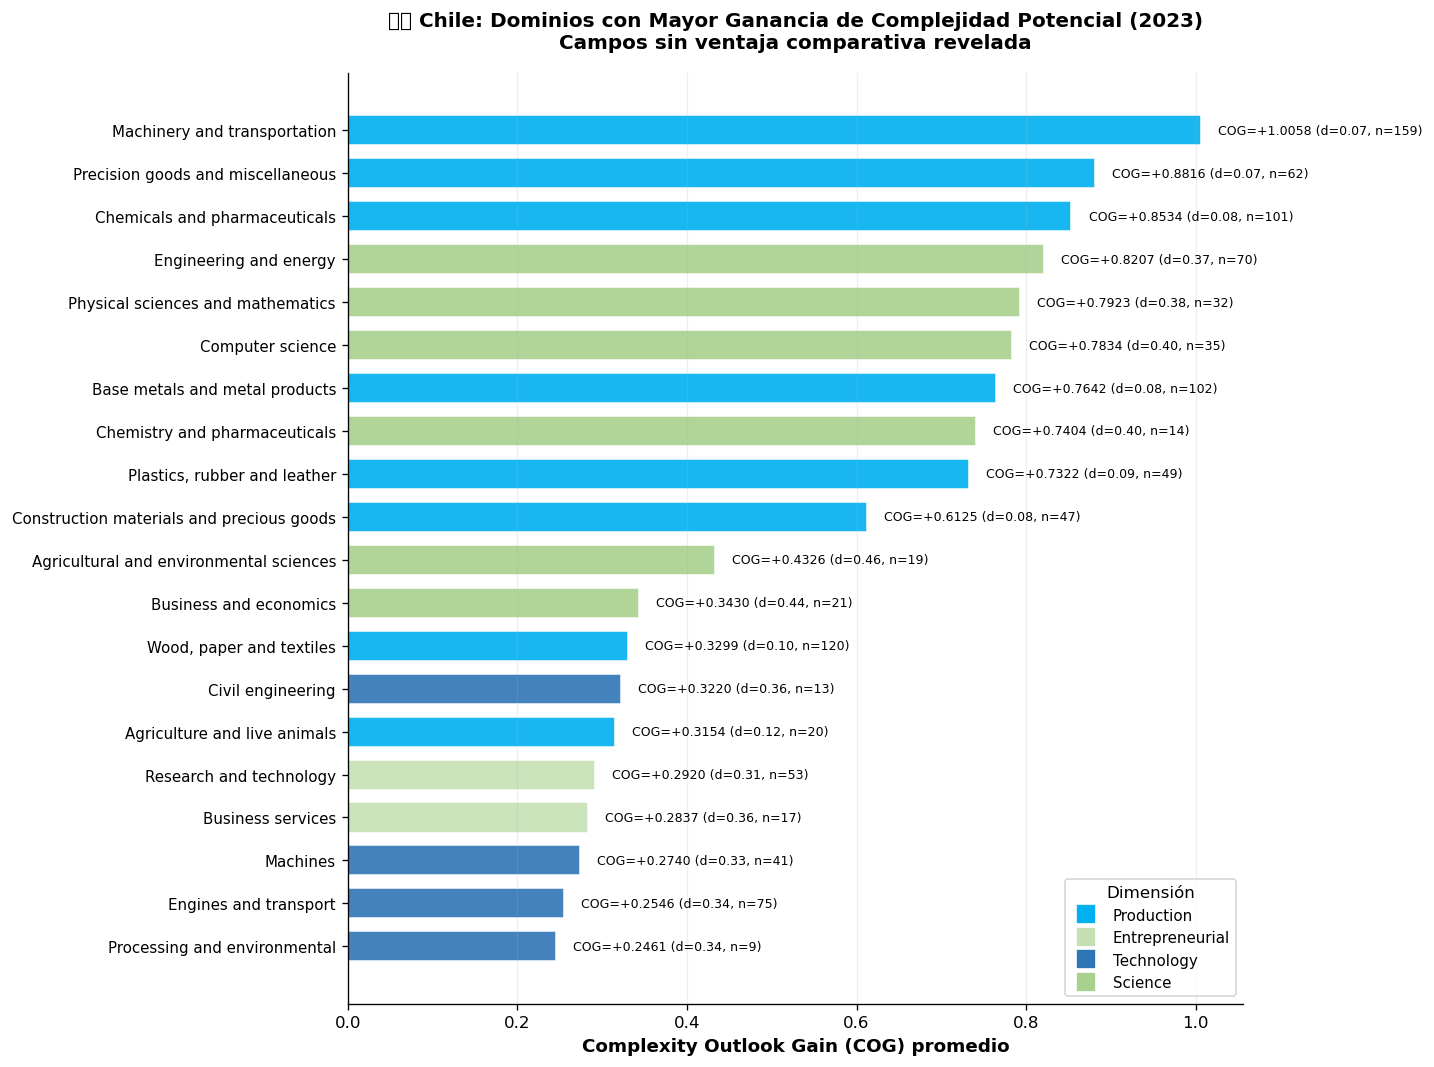

In [11]:
cog_by_domain = chile_no_rca.groupby(['Domain Name', 'Dimension Name']).agg(
    avg_cog=('cog', 'mean'), count=('cog', 'size'), avg_density=('density', 'mean'),
).reset_index()
cog_by_domain = cog_by_domain[cog_by_domain['count'] >= 3]
cog_by_domain = cog_by_domain.sort_values('avg_cog', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(12, 9))
colors = [DIM_COLORS.get(d, '#999') for d in cog_by_domain['Dimension Name']]
ax.barh(range(len(cog_by_domain)), cog_by_domain['avg_cog'], color=colors,
        edgecolor='white', height=0.7, alpha=0.9)
ax.set_yticks(range(len(cog_by_domain)))
ax.set_yticklabels(cog_by_domain['Domain Name'], fontsize=9)

for i, (cog, cnt, dens) in enumerate(zip(cog_by_domain['avg_cog'], cog_by_domain['count'], cog_by_domain['avg_density'])):
    ax.text(cog + max(cog_by_domain['avg_cog'])*0.02, i, f'COG={cog:+.4f} (d={dens:.2f}, n={cnt})', va='center', fontsize=7.5)

legend_elements = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=12, label=d)
                   for d, c in DIM_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Dimensión', title_fontsize=10)
ax.set_xlabel('Complexity Outlook Gain (COG) promedio', fontsize=11, fontweight='bold')
ax.set_title('🇨🇱 Chile: Dominios con Mayor Ganancia de Complejidad Potencial (2023)\nCampos sin ventaja comparativa revelada',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(True, axis='x', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chile_cog_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Product Space: PCI vs Ubiquity

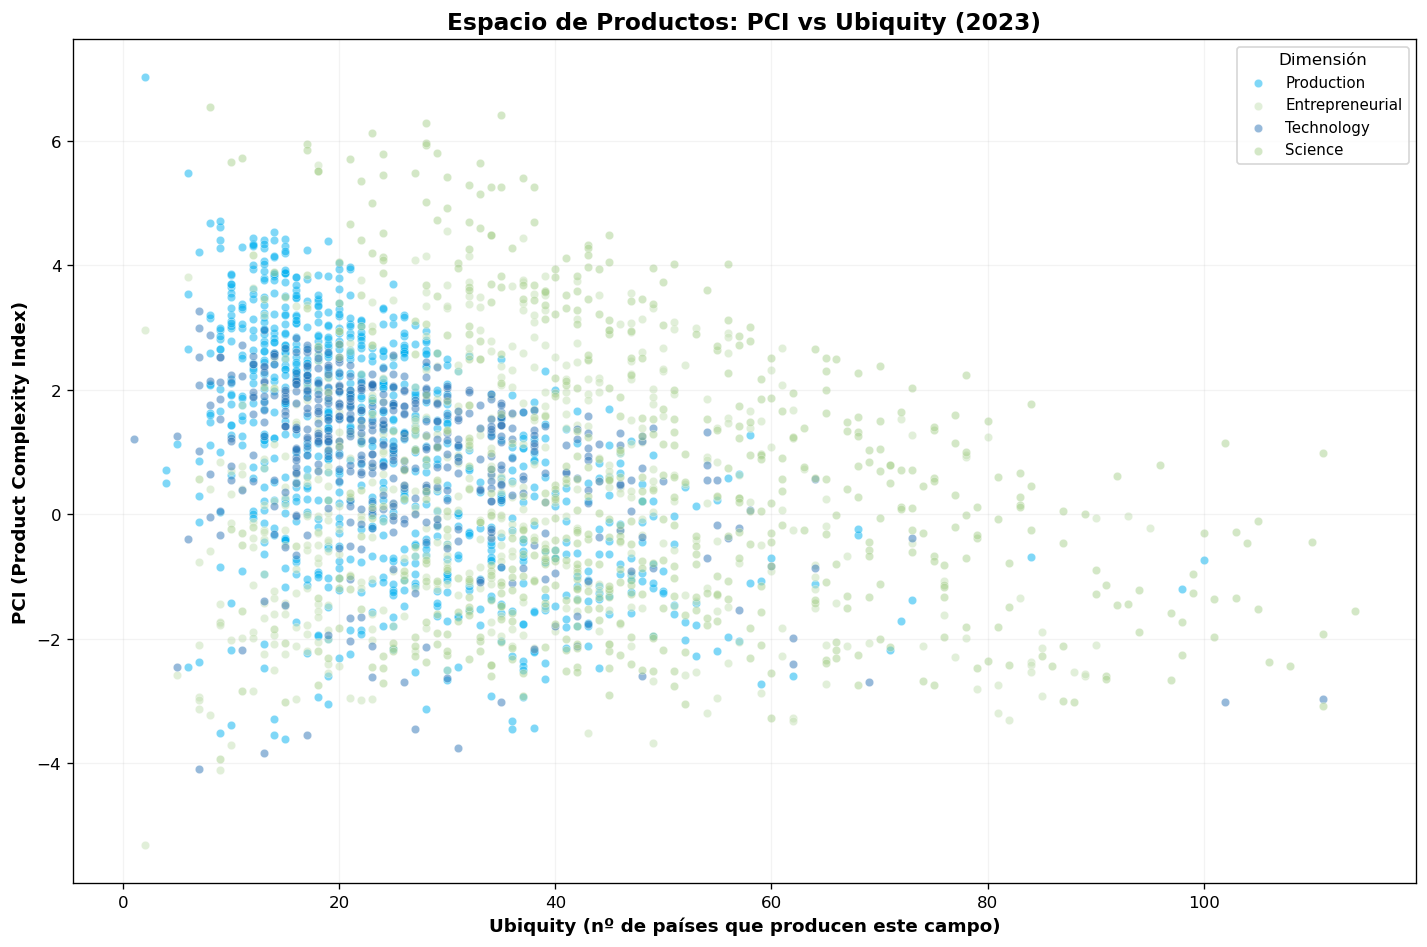

In [12]:
pci_data = all_results[all_results['Period'] == 2023].drop_duplicates(subset=['Field ID', 'Dimension']).merge(fields, on='Field ID', how='left')

fig, ax = plt.subplots(figsize=(12, 8))
for dim, color in DIM_COLORS.items():
    mask = pci_data['Dimension Name'] == dim
    subset = pci_data[mask]
    ax.scatter(subset['ubiquity'], subset['pci'], c=color, s=25, alpha=0.5, label=dim, edgecolors='white', linewidth=0.3)

ax.set_xlabel('Ubiquity (nº de países que producen este campo)', fontweight='bold')
ax.set_ylabel('PCI (Product Complexity Index)', fontweight='bold')
ax.set_title('Espacio de Productos: PCI vs Ubiquity (2023)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, title='Dimensión')
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('product_space_pci_ubiquity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Resumen
- **py-ecomplexity** de Harvard: ECI, PCI, RCA, densidad, COI y COG
- **4 dimensiones** procesadas independientemente (Production, Technology, Science, Entrepreneurial)
- **Chile**: dominios con RCA, oportunidades estratégicas, y COG por dominio